In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

In [ ]:
# Load Dataset
df = pd.read_csv("../data/feedback.csv")

df.head()

,Unique_ID,Category,Review_Header,Review_text,Rating,Own_Rating
0,136040,smartTv,Nice one,I liked it,5,Positive
1,134236,mobile,Huge battery life with amazing display,I bought the phone on Amazon and been using my Samsung M30s for couple of weeks now. Delivery ex...,5,Positive
2,113945,books,Four Stars,"Awesome book at reasonable price, must buy .........",4,Positive
3,168076,smartTv,Nice quality,good,5,Positive
4,157302,books,Nice book,"The book is fine,not bad,contains nice concepts and nicely explained. Likes its concepts.",3,Neutral


In [4]:
# Dataset Shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

# The dataset contains X records and 6 attributes, 
# providing customer review information across product categories, ratings, review text, and sentiment labels.

Number of rows: 60889
Number of columns: 6
Dataset shape: (60889, 6)


In [ ]:
# Check Column Names
print("Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col} ")

# The dataset contains six attributes. Review_Header and Review_text provide textual information for NLP, 
# while Own_Rating serves as the sentiment target.

Columns:
1. Unique_ID 
2. Category 
3. Review_Header 
4. Review_text 
5. Rating 
6. Own_Rating 


In [ ]:
# Basic Dataset Information
df.info()
df.dtypes
# This is important because it determines the preprocessing pipeline later.

<class 'pandas.DataFrame'>
RangeIndex: 60889 entries, 0 to 60888
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Unique_ID      60889 non-null  int64
 1   Category       60889 non-null  str  
 2   Review_Header  60884 non-null  str  
 3   Review_text    60857 non-null  str  
 4   Rating         60889 non-null  int64
 5   Own_Rating     60889 non-null  str  
dtypes: int64(2), str(4)
memory usage: 13.2 MB


Unique_ID        int64
Category           str
Review_Header      str
Review_text        str
Rating           int64
Own_Rating         str
dtype: object

In [10]:
# First 10 Records
df.head(10)


# The sample records show that the dataset contains 
# reviews from categories such as mobile, books, smart TVs, and mobile accessories, 
# with ratings ranging from positive to negative customer experiences.

,Unique_ID,Category,Review_Header,Review_text,Rating,Own_Rating
0,136040,smartTv,Nice one,I liked it,5,Positive
1,134236,mobile,Huge battery life with amazing display,I bought the phone on Amazon and been using my Samsung M30s for couple of weeks now. Delivery ex...,5,Positive
2,113945,books,Four Stars,"Awesome book at reasonable price, must buy .........",4,Positive
3,168076,smartTv,Nice quality,good,5,Positive
4,157302,books,Nice book,"The book is fine,not bad,contains nice concepts and nicely explained. Likes its concepts.",3,Neutral
5,146539,smartTv,Nice tv,Nice tv and pic quality .good custmer srrvice my tv install 3 hours Isme home theater kaise lagega,5,Positive
6,157661,smartTv,Beauty and the Beast,"The iPhone 7 is legitimately among the most interesting, opinionated, powerful phones Apple has ...",5,Positive
7,110329,mobile,"20000 mAH, what more you need","20000 mAH, what more you need. Super product",5,Positive
8,157473,mobile,Need more good quality,The company should give more Bettany backup and screen saver,2,Negative
9,163223,mobile accessories,Good phone,Very good phone,5,Positive


In [11]:
df.tail(10)

,Unique_ID,Category,Review_Header,Review_text,Rating,Own_Rating
60879,150254,smartTv,Nice,Performance is good,5,Positive
60880,110786,books,Five Stars,A must read for all aspirants who seek to conquer English language.,5,Positive
60881,161713,mobile accessories,Valo na,Valo na,1,Negative
60882,144507,refrigerator,Samsung Gear S3 .. Awesome....,Nice ....Watch,5,Positive
60883,110121,mobile accessories,Not Happy facing so much issues,1) 3.5 mm jack is not supporting any kind of headphones. 2) Fingerprint button is also moving he...,1,Negative
60884,148315,smartTv,Good,Ok,4,Positive
60885,162092,smartTv,Five Stars,"Value for money, using since more than 4 months, sound clarity is good",5,Positive
60886,164387,mobile,Best in prise,Very nice products,5,Positive
60887,133063,smartTv,Not gud pbone,Heating problem. Battery backup less than.,3,Neutral
60888,167823,mobile,Not recommend,"fingerprint reader average Camera quality below average compared to same MP camera like OPPO,VIV...",3,Neutral


In [ ]:
# Statistical Summary
df.describe(include="all").T
df.describe()

print("Minimum Rating:", df["Rating"].min())
print("Maximum Rating:", df["Rating"].max())
print("Average Rating:", round(df["Rating"].mean(), 2))
print("Median Rating:", df["Rating"].median())

# The customer rating ranges from 1 to 2, 
# with an average rating of 4.

Minimum Rating: 1
Maximum Rating: 5
Average Rating: 4.08
Median Rating: 5.0


In [ ]:
# Missing Value Analysis
missing = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percentage
})

missing_table

text_columns = ["Review_Header", "Review_text"]

for col in text_columns:
    empty_count = (df[col].fillna("").str.strip() == "").sum()
    print(f"{col} - Empty values:", empty_count)

# Missing values were identified in 
# Review_Header and Review_text. 
# These will be handled during Phase 3 preprocessing.

Review_Header - Empty values: 5
Review_text - Empty values: 32


In [ ]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

duplicate_ids = df["Unique_ID"].duplicated().sum()

print("Duplicate Unique_ID values:", duplicate_ids)

df[df["Unique_ID"].duplicated(keep=False)].sort_values("Unique_ID")

# No duplicate records or duplicate Unique_ID values were identified.



Duplicate rows: 0
Duplicate Unique_ID values: 0


,Unique_ID,Category,Review_Header,Review_text,Rating,Own_Rating


Category
mobile                22749
mobile accessories    14811
smartTv               14624
refrigerator           4791
books                  3914
Name: count, dtype: int64
Number of unique categories: 5


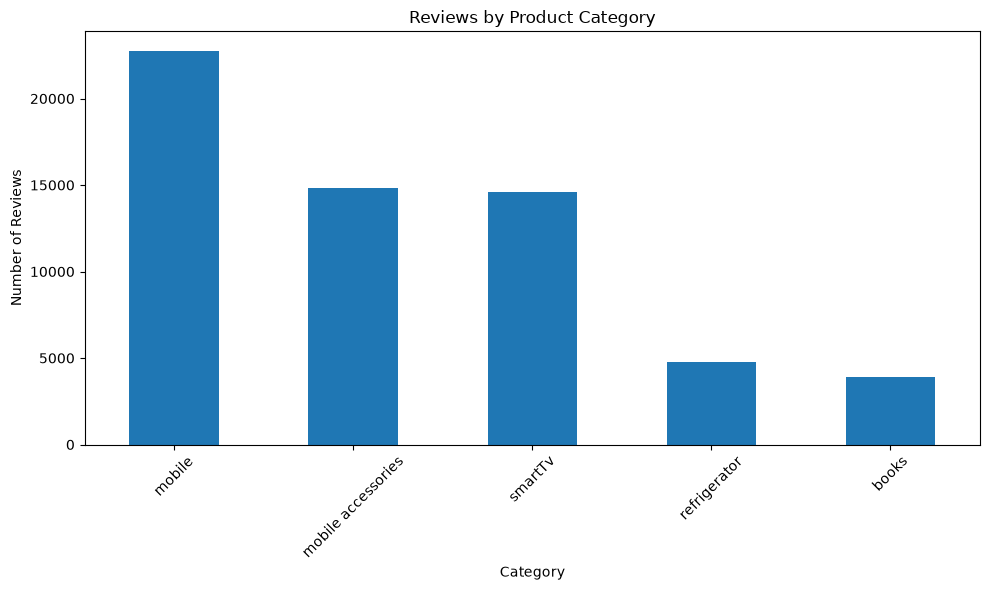

In [ ]:
# Category Analysis
category_counts = df["Category"].value_counts()

print(category_counts)

print("Number of unique categories:", df["Category"].nunique())

plt.figure(figsize=(10, 6))

category_counts.plot(kind="bar")

plt.title("Reviews by Product Category")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# The dataset contains 5 product categories. 
# The category with the highest number of reviews is mobile, 
# while the category with the lowest number is books.


Rating
1     6979
2     2108
3     4366
4    12976
5    34460
Name: count, dtype: int64


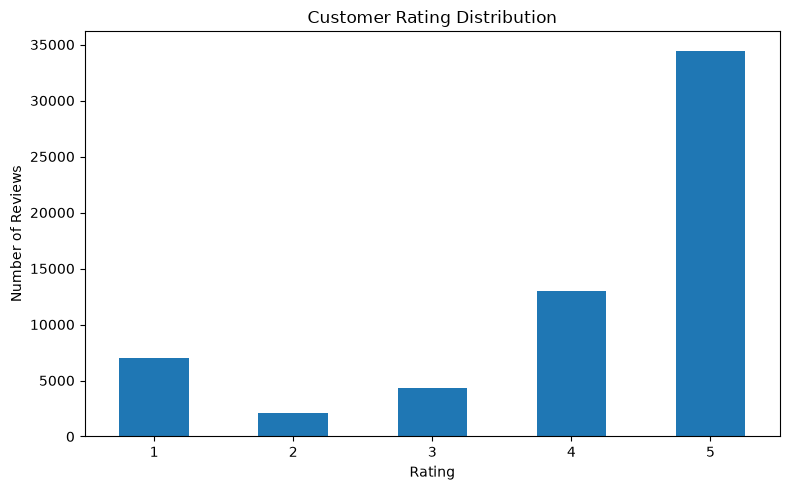

Most common rating: 5


In [ ]:
 # Rating Distribution
rating_counts = df["Rating"].value_counts().sort_index()

print(rating_counts)

plt.figure(figsize=(8, 5))

rating_counts.plot(kind="bar")

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

most_common_rating = df["Rating"].mode()[0]

print("Most common rating:", most_common_rating)

# The most common customer rating is 5, 
# indicating that the dataset contains a relatively large number of reviews with this rating

Own_Rating
Positive    47436
Negative     9087
Neutral      4366
Name: count, dtype: int64
Own_Rating
Positive    77.91
Negative    14.92
Neutral      7.17
Name: proportion, dtype: float64


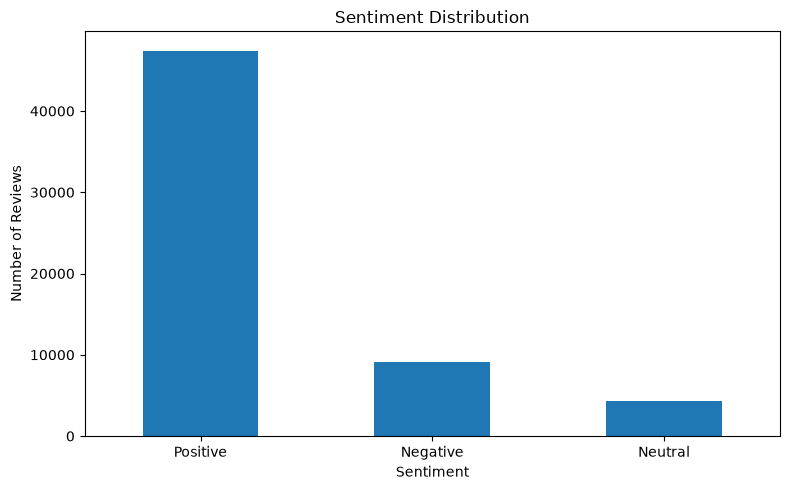

Dominant sentiment: Positive


In [ ]:
sentiment_counts = df["Own_Rating"].value_counts()

print(sentiment_counts)

sentiment_percentage = (
    df["Own_Rating"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_percentage)

plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

dominant_sentiment = df["Own_Rating"].value_counts().idxmax()

print("Dominant sentiment:", dominant_sentiment)

# The sentiment classes are Positive, Neutral, and Negative. 
# The dominant sentiment class is X, accounting for approximately Y% of the dataset.

Own_Rating  Negative  Neutral  Positive
Rating                                 
1               6979        0         0
2               2108        0         0
3                  0     4366         0
4                  0        0     12976
5                  0        0     34460
Own_Rating  Negative  Neutral  Positive
Rating                                 
1              100.0      0.0       0.0
2              100.0      0.0       0.0
3                0.0    100.0       0.0
4                0.0      0.0     100.0
5                0.0      0.0     100.0


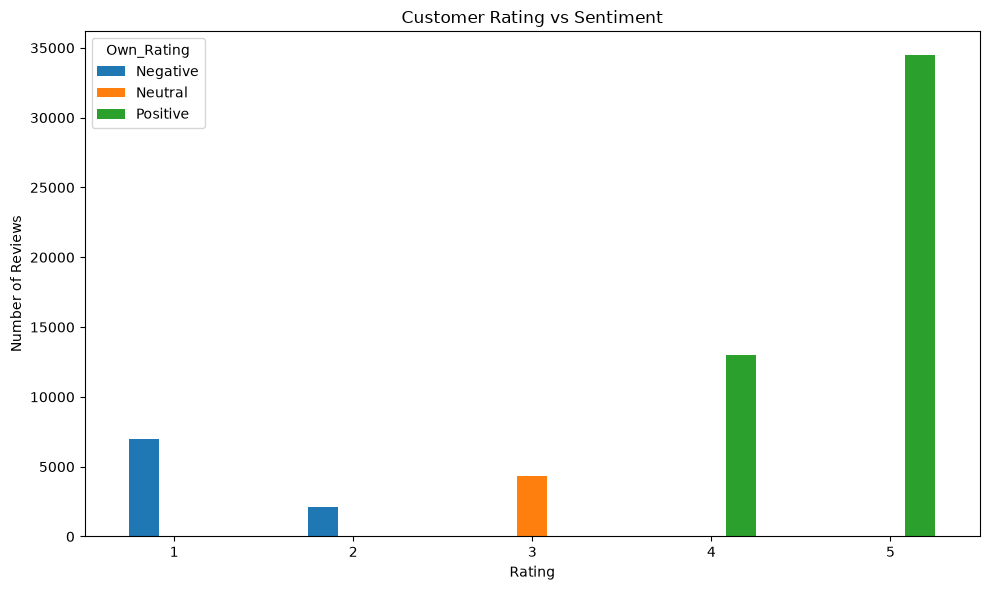

In [23]:
# Rating vs Sentiment
rating_sentiment = pd.crosstab(
    df["Rating"],
    df["Own_Rating"]
)

print(rating_sentiment)

rating_sentiment_percentage = pd.crosstab(
    df["Rating"],
    df["Own_Rating"],
    normalize="index"
).mul(100).round(2)

print(rating_sentiment_percentage)

rating_sentiment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer Rating vs Sentiment")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
# Review Text Analysis
df["review_text_length"] = (
    df["Review_text"]
    .fillna("")
    .astype(str)
    .str.len()
)

df["review_word_count"] = (
    df["Review_text"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

print(df[["review_text_length", "review_word_count"]].describe())

print(
    "Average review length:",
    round(df["review_text_length"].mean(), 2)
)

print(
    "Average word count:",
    round(df["review_word_count"].mean(), 2))

       review_text_length  review_word_count
count        60889.000000       60889.000000
mean           141.179786          25.558525
std            309.785111          56.151736
min              0.000000           0.000000
25%             18.000000           3.000000
50%             61.000000          11.000000
75%            158.000000          28.000000
max          18256.000000        3318.000000
Average review length: 141.18
Average word count: 25.56


In [ ]:
# Very Short Reviews
short_reviews = df[
    df["review_word_count"] <= 3
]

print("Reviews with 3 or fewer words:", len(short_reviews))

short_reviews[
    ["Unique_ID", "Review_Header", "Review_text", "Rating", "Own_Rating"]
].head(20)

# The dataset contains both detailed reviews and very short reviews. 
# This is important for NLP because short texts provide fewer linguistic features for sentiment classification.

# useful observation for your project report.

Reviews with 3 or fewer words: 15996


,Unique_ID,Review_Header,Review_text,Rating,Own_Rating
0,136040,Nice one,I liked it,5,Positive
3,168076,Nice quality,good,5,Positive
9,163223,Good phone,Very good phone,5,Positive
10,128878,Good option for AI home,Good option,4,Positive
12,126986,Thank you,Good,5,Positive
14,130407,Four Stars,Good product 👍,4,Positive
15,128968,Good phone,Good phone,5,Positive
18,112316,Awesome,Amazing phone,5,Positive
19,162756,.,Very good,5,Positive
30,163138,Good,Very good mobile,4,Positive


In [32]:
# Review Header Analysis
df["header_word_count"] = (
    df["Review_Header"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

print(df["header_word_count"].describe())

df[
    ["Review_Header", "Review_text", "Own_Rating"]
].head(10)

# Review_Header provides a short summary of the customer's opinion 
# and can be combined with Review_text to provide additional textual information to the NLP model.

count    60889.000000
mean         3.512161
std          2.794808
min          0.000000
25%          2.000000
50%          2.000000
75%          5.000000
max         31.000000
Name: header_word_count, dtype: float64


,Review_Header,Review_text,Own_Rating
0,Nice one,I liked it,Positive
1,Huge battery life with amazing display,I bought the phone on Amazon and been using my Samsung M30s for couple of weeks now. Delivery ex...,Positive
2,Four Stars,"Awesome book at reasonable price, must buy .........",Positive
3,Nice quality,good,Positive
4,Nice book,"The book is fine,not bad,contains nice concepts and nicely explained. Likes its concepts.",Neutral
5,Nice tv,Nice tv and pic quality .good custmer srrvice my tv install 3 hours Isme home theater kaise lagega,Positive
6,Beauty and the Beast,"The iPhone 7 is legitimately among the most interesting, opinionated, powerful phones Apple has ...",Positive
7,"20000 mAH, what more you need","20000 mAH, what more you need. Super product",Positive
8,Need more good quality,The company should give more Bettany backup and screen saver,Negative
9,Good phone,Very good phone,Positive


Own_Rating          Negative  Neutral  Positive
Category                                       
books                    207      189      3518
mobile                  3494     1736     17519
mobile accessories      2436     1231     11144
refrigerator             586      275      3930
smartTv                 2364      935     11325


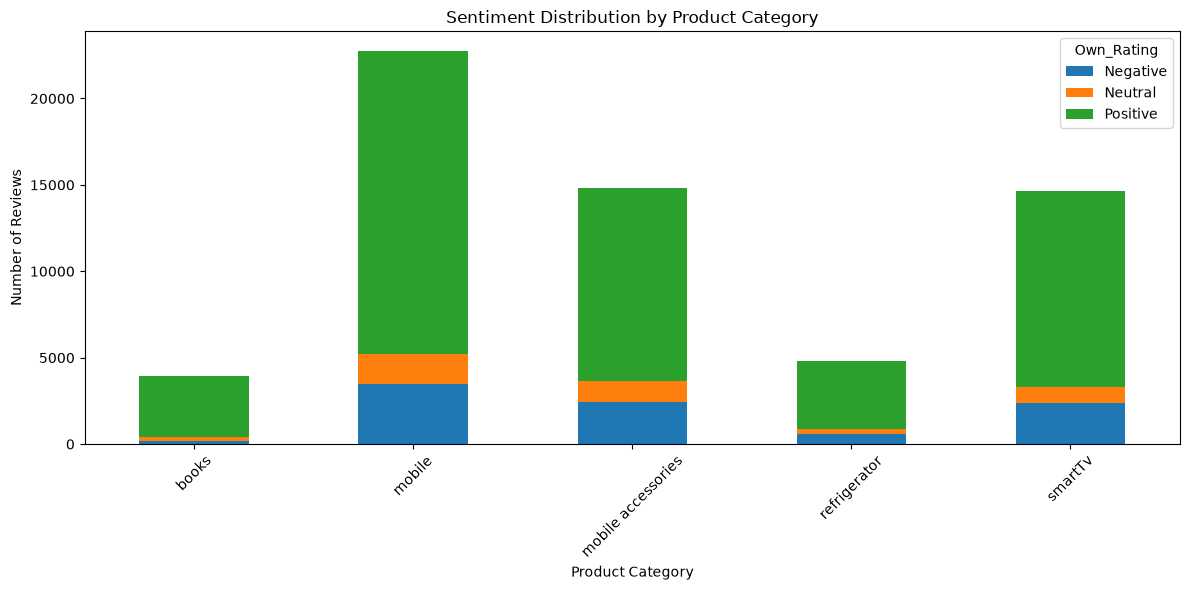

Own_Rating,Negative,Neutral,Positive
Category,,,
books,5.29,4.83,89.88
mobile,15.36,7.63,77.01
mobile accessories,16.45,8.31,75.24
refrigerator,12.23,5.74,82.03
smartTv,16.17,6.39,77.44


In [ ]:
# Category vs Sentiment

# Useful for products page
category_sentiment = pd.crosstab(
    df["Category"],
    df["Own_Rating"]
)

print(category_sentiment)

category_sentiment_percentage = pd.crosstab(
    df["Category"],
    df["Own_Rating"],
    normalize="index"
).mul(100).round(2)



category_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Sentiment Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

category_sentiment_percentage

#You can identify:

#Category with most positive reviews
#Category with most negative reviews
#Category with most neutral reviews

Category
books                 4.54
refrigerator          4.21
smartTv               4.06
mobile                4.06
mobile accessories    3.98
Name: Rating, dtype: float64


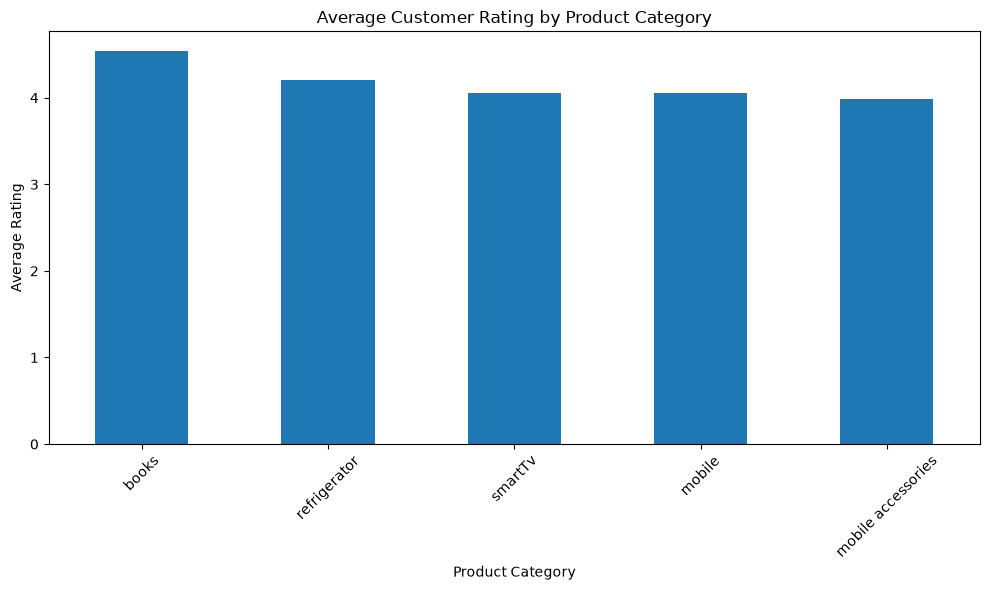

In [ ]:
# Average Rating by Category
average_rating_category = (
    df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print(average_rating_category)

plt.figure(figsize=(10, 6))

average_rating_category.plot(kind="bar")

plt.title("Average Customer Rating by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Product categories show different levels of customer satisfaction, as reflected by their average ratings.
#  The highest- and lowest-rated categories can be identified for further business analysis.

In [40]:
# Final Data Quality Summary
print("========== DATASET SUMMARY ==========")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate Unique_ID:")
print(df["Unique_ID"].duplicated().sum())

print("\nUnique categories:")
print(df["Category"].nunique())

print("\nCategories:")
print(df["Category"].unique())

print("\nRating distribution:")
print(df["Rating"].value_counts().sort_index())

print("\nSentiment distribution:")
print(df["Own_Rating"].value_counts())

print("\nAverage rating:")
print(round(df["Rating"].mean(), 2))

========== DATASET SUMMARY ==========
Rows: 60889
Columns: 9

Missing values:
Unique_ID              0
Category               0
Review_Header          5
Review_text           32
Rating                 0
Own_Rating             0
review_text_length     0
review_word_count      0
header_word_count      0
dtype: int64

Duplicate rows:
0

Duplicate Unique_ID:
0

Unique categories:
5

Categories:
<ArrowStringArray>
['smartTv', 'mobile', 'books', 'mobile accessories', 'refrigerator']
Length: 5, dtype: str

Rating distribution:
Rating
1     6979
2     2108
3     4366
4    12976
5    34460
Name: count, dtype: int64

Sentiment distribution:
Own_Rating
Positive    47436
Negative     9087
Neutral      4366
Name: count, dtype: int64

Average rating:
4.08


In [41]:
"""Phase 1 Final Insights

After running the notebook, your Phase 1 report should have a section like this:

Dataset Insights
Dataset structure:
The dataset contains X rows and 6 columns: Unique_ID, Category, Review_Header, Review_text, Rating, and Own_Rating.
NLP suitability:
Review_Header and Review_text provide textual information suitable for sentiment-analysis modeling.
Target variable:
Own_Rating contains the sentiment classes Positive, Neutral, and Negative, making it the target variable for supervised classification.
Rating:
Customer ratings range from X to Y, with an average rating of X.
Category distribution:
The dataset contains X unique product categories, with X having the highest number of reviews.
Sentiment distribution:
X is the dominant sentiment class, representing approximately X% of all records.
Data quality:
There are X missing values and X duplicate rows. These findings will determine the cleaning strategy in Phase 3.
Review quality:
The dataset contains both short and long reviews. Very short reviews may provide limited textual information for NLP classification.
Category-sentiment relationship:
Sentiment proportions vary across product categories, providing useful information for the Analytics and Products pages.
Rating-sentiment relationship:
The relationship between Rating and Own_Rating should be examined carefully before model development to avoid creating an overly easy or misleading NLP model."""

'Phase 1 Final Insights\n\nAfter running the notebook, your Phase 1 report should have a section like this:\n\nDataset Insights\nDataset structure:\nThe dataset contains X rows and 6 columns: Unique_ID, Category, Review_Header, Review_text, Rating, and Own_Rating.\nNLP suitability:\nReview_Header and Review_text provide textual information suitable for sentiment-analysis modeling.\nTarget variable:\nOwn_Rating contains the sentiment classes Positive, Neutral, and Negative, making it the target variable for supervised classification.\nRating:\nCustomer ratings range from X to Y, with an average rating of X.\nCategory distribution:\nThe dataset contains X unique product categories, with X having the highest number of reviews.\nSentiment distribution:\nX is the dominant sentiment class, representing approximately X% of all records.\nData quality:\nThere are X missing values and X duplicate rows. These findings will determine the cleaning strategy in Phase 3.\nReview quality:\nThe dataset 